<!-- KERNEL_BANNER -->
> **Use kernel: `mrigi_tor190_v8`**
>
> Set the notebook kernel to *Python (mrigi_tor190_v8)* before running.

# 30f: GPT-5.2 (no context) vs the best CoT fine-tunes

Table 1 row 1 — **GPT-5.2** — has never been run through the pipeline. This notebook
closes that gap for the **no-context** condition only:

1. **Generate** answers to the same 100 open-ended questions using `gpt-5.2`, with the
   **verbatim no-context prompt from 23j**, so it is prompted identically to every
   open-weight model.
2. **Judge** correctness with the **same prompt and both judges** (`gpt-4.1`, `gpt-4o`)
   used in 30b.
3. **Compare** against the open-weight models, with paired per-question tests on matched
   questions.

**Fairness note.** GPT-5.2 answers from parametric knowledge alone. The headline
comparison is therefore against the open-weight models *in their no-context condition*.
The comparison against their RAG condition is also reported, but that is a
**retrieval-augmented vs non-augmented** contrast, not a like-for-like model comparison.

**Cost.** ~100 generation calls + ~200 judge calls. Generation is cached to
`results_gpt52_nocontext_*.json`; judging is cached to `judge_results_gpt52_*.json`.
Re-running reuses both.

In [1]:
import os
import json
import glob
import time
import httpx
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.stats import wilcoxon

with open('/home/jupyter/Mrigi/env.sh') as f:
    for line in f:
        line = line.strip()
        if line.startswith('export ') and '=' in line:
            k, v = line[len('export '):].split('=', 1)
            os.environ[k] = v.strip('"').strip("'")

OPENAI_KEY = os.environ.get('OPENAI_API_TOKEN')
if not OPENAI_KEY:
    raise ValueError('OPENAI_API_TOKEN missing from /home/jupyter/Mrigi/env.sh')
HEADERS = {'Authorization': f'Bearer {OPENAI_KEY}', 'Content-Type': 'application/json'}
API = 'https://api.openai.com/v1/chat/completions'

GEN_MODEL   = 'gpt-5.2'                  # pin to 'gpt-5.2-2025-12-11' for exact reproducibility
JUDGES      = ['gpt-4.1', 'gpt-4o']      # identical to 30b
MAX_TOKENS  = 400                        # matches 23j's max_new_tokens=400
WORKERS     = 8
TS          = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f'key ...{OPENAI_KEY[-4:]}   generator: {GEN_MODEL}   judges: {JUDGES}')

# Fail loudly and early if billing is not live, rather than 300 calls later.
_probe = httpx.post(API, headers=HEADERS, timeout=60,
                    json={'model': 'gpt-4o-mini',
                          'messages': [{'role': 'user', 'content': 'hi'}],
                          'max_tokens': 1})
if _probe.status_code != 200:
    msg = _probe.json().get('error', {}).get('message', '')
    raise RuntimeError(f'API not usable (HTTP {_probe.status_code}): {msg[:200]}')
print('\u2713 billing live - safe to proceed')

key ...GmYA   generator: gpt-5.2   judges: ['gpt-4.1', 'gpt-4o']
✓ billing live - safe to proceed


In [2]:
# ---------------------------------------------------------------------------
# Prompts. Both are verbatim copies of the prompts already used in the pipeline:
#   - generation  : 23j NO_CONTEXT_OPEN_ENDED_PROMPT
#   - judging     : 30b OPEN_ENDED_CORRECTNESS_PROMPT + JUDGE_SYSTEM_PROMPT
# Changing either would break comparability with the existing results.
# ---------------------------------------------------------------------------
NO_CONTEXT_OPEN_ENDED_PROMPT = """You are an expert on zeolite synthesis, chemistry, and catalysis. Answer the following question using your own knowledge. Give a clear, focused answer in 3\u20135 sentences (or fewer if the question is simple). Do not invent citations. Do not restate the question.

Question: {question}

Answer:"""

JUDGE_SYSTEM_PROMPT = """You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system 
focused on zeolite synthesis, catalysis, and environmental applications. 
You will evaluate the quality of retrieved contexts and open-ended generated responses 
against a reference (gold) answer.
Always respond in valid JSON format."""

OPEN_ENDED_CORRECTNESS_PROMPT = """Given the following query, a reference (gold) answer, and a model's open-ended response, rate how correct the response is.

Judge on scientific substance, not wording. The response may phrase things differently, be more or less detailed, or add related information \u2014 that is fine as long as the core claim matches the reference and any additional claims are accurate.

**Scoring Rubric (1-10):**
- 1-2: Completely incorrect \u2014 asserts something that contradicts the reference answer
- 3-4: Mostly incorrect \u2014 misses the main point, but shows partial understanding of the topic
- 5-6: Partially correct \u2014 captures part of the reference answer but is missing or muddling the key idea
- 7-8: Mostly correct \u2014 captures the key idea of the reference answer, with minor gaps or imprecise phrasing
- 9-10: Fully correct \u2014 captures the reference answer's key idea clearly and accurately (extra correct detail is fine)

**Query:**
{query}

**Reference (Gold) Answer:**
{gold_answer}

**Model's Open-Ended Response:**
{response}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

print('\u2713 prompts loaded (verbatim from 23j / 30b)')

✓ prompts loaded (verbatim from 23j / 30b)


In [3]:
# ---------------------------------------------------------------------------
# Raw-HTTP call helper.
#
# The installed openai SDK is 1.3.8, which predates `max_completion_tokens` and
# rejects it client-side with a TypeError. GPT-5.x reasoning models in turn may
# reject `max_tokens` and/or a non-default `temperature`. Posting the JSON body
# directly sidesteps the SDK entirely, and the helper below negotiates whichever
# parameter spelling the target model actually accepts.
# ---------------------------------------------------------------------------
def chat(model, messages, max_tokens=None, temperature=None,
         json_mode=False, max_retries=4, timeout=180):
    body = {'model': model, 'messages': messages}
    if json_mode:
        body['response_format'] = {'type': 'json_object'}
    if temperature is not None:
        body['temperature'] = temperature
    token_key = 'max_tokens'
    if max_tokens is not None:
        body[token_key] = max_tokens

    for attempt in range(max_retries):
        try:
            r = httpx.post(API, headers=HEADERS, json=body, timeout=timeout)
        except Exception as e:
            if attempt == max_retries - 1:
                return None, f'network: {e}'
            time.sleep(3 * (attempt + 1)); continue

        if r.status_code == 200:
            return r.json(), None

        err = r.json().get('error', {})
        msg = err.get('message', '')

        # --- parameter negotiation (does not consume a retry) ---
        if 'max_completion_tokens' in msg and token_key in body:
            body['max_completion_tokens'] = body.pop(token_key)
            token_key = 'max_completion_tokens'
            continue
        if 'temperature' in msg and 'temperature' in body:
            body.pop('temperature')
            continue
        if 'response_format' in msg and 'response_format' in body:
            body.pop('response_format')
            continue

        if r.status_code == 429 and 'credit' in msg.lower():
            return None, f'billing: {msg[:160]}'      # no point retrying
        if attempt == max_retries - 1:
            return None, f'HTTP {r.status_code}: {msg[:160]}'
        time.sleep(4 * (attempt + 1))
    return None, 'max retries exceeded'


print('\u2713 chat() helper ready (auto-negotiates max_tokens / temperature / response_format)')

✓ chat() helper ready (auto-negotiates max_tokens / temperature / response_format)


## Step 1 — Generate GPT-5.2 answers (no context)

In [4]:
# Question set + gold answers are taken from an already-judged open-weight model so
# GPT-5.2 is scored on byte-identical inputs.
JUDGE_FILE = sorted(glob.glob('judge_results_23j_dual_final_*.json'), key=os.path.getmtime)[-1]
REF = json.load(open(JUDGE_FILE))['results']
_template = REF['Llama-3-8B-Instruct']['no_context']
QUESTIONS = [{'q_idx': i, 'query': r['query'], 'gold': r['gold_answer'],
              'title': r.get('title'), 'doi': r.get('doi')}
             for i, r in enumerate(_template) if r]
print(f'reference judge file : {JUDGE_FILE}')
print(f'questions            : {len(QUESTIONS)}')

cached = sorted(glob.glob('results_gpt52_nocontext_*.json'), key=os.path.getmtime)
gpt52 = None
if cached:
    payload = json.load(open(cached[-1]))
    recs = payload.get('detailed_results', [])
    ok = sum(1 for r in recs if r.get('model_answer') not in ('ERROR', 'INVALID', '', None))
    if recs and ok >= 0.9 * len(recs):
        gpt52 = recs
        print(f'\u2713 reusing cached generation {cached[-1]}  ({ok}/{len(recs)} valid)')

if gpt52 is None:
    def gen_one(item):
        prompt = NO_CONTEXT_OPEN_ENDED_PROMPT.format(question=item['query'])
        js, err = chat(GEN_MODEL, [{'role': 'user', 'content': prompt}],
                       max_tokens=MAX_TOKENS, temperature=0.1)
        if err:
            return item['q_idx'], {**item, 'model_answer': 'ERROR', 'error': err}
        txt = (js['choices'][0]['message']['content'] or '').strip()
        return item['q_idx'], {**item,
                               'model_answer': txt if txt else 'INVALID',
                               'completion_tokens': js.get('usage', {}).get('completion_tokens')}

    out = [None] * len(QUESTIONS)
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futs = [ex.submit(gen_one, it) for it in QUESTIONS]
        for fut in tqdm(as_completed(futs), total=len(futs), desc=f'generating {GEN_MODEL}'):
            i, rec = fut.result(); out[i] = rec
    gpt52 = out

    n_ok = sum(1 for r in gpt52 if r.get('model_answer') not in ('ERROR', 'INVALID'))
    path = f'results_gpt52_nocontext_{TS}.json'
    with open(path, 'w') as f:
        json.dump({'model': 'GPT-5.2', 'model_id': GEN_MODEL, 'method': 'no_context',
                   'prompt': NO_CONTEXT_OPEN_ENDED_PROMPT, 'max_tokens': MAX_TOKENS,
                   'timestamp': TS, 'n_valid': n_ok, 'total': len(gpt52),
                   'detailed_results': gpt52}, f, indent=2)
    print(f'\n\u2713 saved {path}  ({n_ok}/{len(gpt52)} valid)')
    errs = [r for r in gpt52 if r.get('model_answer') == 'ERROR'][:3]
    for e in errs:
        print(f'   sample error: {e.get("error", "")[:140]}')

print(f'\nsample answer:\n{gpt52[0]["model_answer"][:400]}')

reference judge file : judge_results_23j_dual_final_20260802_184737.json
questions            : 100


generating gpt-5.2:   0%|          | 0/100 [00:00<?, ?it/s]

generating gpt-5.2: 100%|██████████| 100/100 [00:41<00:00,  2.39it/s]


✓ saved results_gpt52_nocontext_20260803_004922.json  (100/100 valid)

sample answer:
An organic dication like hexamethonium most plausibly acts as a structure‑directing/space‑filling agent that biases which composite building units and channel topology are stabilized during nucleation, rather than simply balancing charge. By fitting (or misfitting) specific pore environments and by organizing silicate/aluminosilicate oligomers through electrostatic and hydrophobic interactions, it


## Step 2 — Judge correctness (same prompt and judges as 30b)

In [5]:
cached_j = sorted(glob.glob('judge_results_gpt52_*.json'), key=os.path.getmtime)
gpt52_scores = None
if cached_j:
    p = json.load(open(cached_j[-1]))
    if p.get('judges') == JUDGES and len(p.get('results', [])) == len(gpt52):
        gpt52_scores = p['results']
        print(f'\u2713 reusing cached judgments {cached_j[-1]}')

if gpt52_scores is None:
    def judge_one(rec):
        idx = rec['q_idx']
        if rec.get('model_answer') in ('ERROR', 'INVALID'):
            return idx, {j: {'score': -1, 'reasoning': 'generator ERROR/INVALID'} for j in JUDGES}
        user = OPEN_ENDED_CORRECTNESS_PROMPT.format(
            query=rec['query'], gold_answer=rec['gold'], response=rec['model_answer'])
        per = {}
        for jm in JUDGES:
            js, err = chat(jm, [{'role': 'system', 'content': JUDGE_SYSTEM_PROMPT},
                                {'role': 'user', 'content': user}],
                           max_tokens=200, temperature=0.1, json_mode=True)
            if err:
                per[jm] = {'score': -1, 'reasoning': err}; continue
            try:
                parsed = json.loads(js['choices'][0]['message']['content'].strip())
                sc = int(parsed.get('score', -1))
                per[jm] = {'score': sc if 1 <= sc <= 10 else -1,
                           'reasoning': parsed.get('reasoning', '')}
            except Exception as e:
                per[jm] = {'score': -1, 'reasoning': f'parse error: {e}'}
        return idx, per

    scores = [None] * len(gpt52)
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futs = [ex.submit(judge_one, r) for r in gpt52]
        for fut in tqdm(as_completed(futs), total=len(futs), desc='judging correctness'):
            i, per = fut.result(); scores[i] = per
    gpt52_scores = scores

    path = f'judge_results_gpt52_{TS}.json'
    with open(path, 'w') as f:
        json.dump({'model': 'GPT-5.2', 'model_id': GEN_MODEL, 'judges': JUDGES,
                   'task': 'correctness', 'timestamp': TS,
                   'prompt': OPEN_ENDED_CORRECTNESS_PROMPT,
                   'results': gpt52_scores}, f, indent=2)
    print(f'\u2713 saved {path}')

for jm in JUDGES:
    v = [s[jm]['score'] for s in gpt52_scores if s[jm]['score'] > 0]
    print(f'   GPT-5.2 correctness [{jm}]: {np.mean(v):.2f}  (n={len(v)})')

judging correctness: 100%|██████████| 100/100 [01:09<00:00,  1.44it/s]

✓ saved judge_results_gpt52_20260803_004922.json
   GPT-5.2 correctness [gpt-4.1]: 9.91  (n=99)
   GPT-5.2 correctness [gpt-4o]: 9.16  (n=100)


## Step 3 — Compare against the open-weight models

In [6]:
TABLE1 = [('Llama-3-8B-Instruct', 'Llama-3-8B-Instruct', False),
          ('base_llama_COT', 'Llama-3-8B-Instruct + CoT FT', True),
          ('DAPT_LR1e5', 'Broad abstracts DAPT', False),
          ('DAPT_LR1e5_COT', 'Broad abstracts DAPT + CoT FT', True),
          ('synv2V2_step80', 'Synthesis abstracts DAPT', False),
          ('synv2V2_step80_COT', 'Synthesis abstracts DAPT + CoT FT', True),
          ('synv2_base_step80_COT', 'Synthesis abstracts DAPT (base LM) + CoT FT', True),
          ('fullpaper_120M_LR1e5', 'Synthesis full-paper DAPT', False),
          ('fullpaper_120M_COT', 'Synthesis full-paper DAPT + CoT FT', True)]
PRIMARY = 'gpt-4.1'


def local_scores(internal, cond, judge=PRIMARY):
    """q_idx -> correctness score for an open-weight model."""
    return {i: r['judges'][judge]['correctness_score']
            for i, r in enumerate(REF[internal].get(cond) or [])
            if r and r['judges'][judge]['correctness_score'] > 0}


def gpt52_by_q(judge=PRIMARY):
    return {i: s[judge]['score'] for i, s in enumerate(gpt52_scores) if s[judge]['score'] > 0}


rows = []
for internal, label, is_cot in TABLE1:
    for cond in ('no_context', 'mmr'):
        for jm in JUDGES:
            g, l = gpt52_by_q(jm), local_scores(internal, cond, jm)
            common = sorted(set(g) & set(l))
            d = np.array([g[i] - l[i] for i in common], float)   # + => GPT-5.2 better
            p = wilcoxon(d).pvalue if len(d) > 2 and np.any(d) else np.nan
            rows.append({'model': label, 'internal': internal, 'is_cot': is_cot,
                         'condition': cond, 'judge': jm, 'n': len(common),
                         'local_mean': float(np.mean([l[i] for i in common])),
                         'gpt52_mean': float(np.mean([g[i] for i in common])),
                         'delta': float(d.mean()), 'p': p,
                         'gpt52_wins': int((d > 0).sum()), 'losses': int((d < 0).sum()),
                         'ties': int((d == 0).sum())})
cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(f'gpt52_vs_local_{TS}.csv', index=False)


def stars(p):
    if not np.isfinite(p): return ''
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < .05 else 'n.s.'


g41 = np.mean(list(gpt52_by_q('gpt-4.1').values()))
print('=' * 92)
print(f'GPT-5.2 (no context) correctness = {g41:.2f}   [judge {PRIMARY}]')
print('=' * 92)
print('\nHEAD-TO-HEAD vs each model, no-context condition (like-for-like):')
print(f'{"model":<46}{"local":>7}{"GPT-5.2":>9}{"delta":>8}{"W/L/T":>14}  sig')
print('-' * 92)
sub = cmp_df[(cmp_df.condition == 'no_context') & (cmp_df.judge == PRIMARY)]
for _, r in sub.iterrows():
    print(f'{r.model:<46}{r.local_mean:>7.2f}{r.gpt52_mean:>9.2f}{r.delta:>+8.2f}'
          f'{f"{r.gpt52_wins}/{r.losses}/{r.ties}":>14}  {stars(r.p)}')

print('\nvs each model WITH retrieval (GPT-5.2 has no retrieval - not like-for-like):')
print(f'{"model":<46}{"local":>7}{"GPT-5.2":>9}{"delta":>8}{"W/L/T":>14}  sig')
print('-' * 92)
sub = cmp_df[(cmp_df.condition == 'mmr') & (cmp_df.judge == PRIMARY)]
for _, r in sub.iterrows():
    print(f'{r.model:<46}{r.local_mean:>7.2f}{r.gpt52_mean:>9.2f}{r.delta:>+8.2f}'
          f'{f"{r.gpt52_wins}/{r.losses}/{r.ties}":>14}  {stars(r.p)}')

GPT-5.2 (no context) correctness = 9.91   [judge gpt-4.1]

HEAD-TO-HEAD vs each model, no-context condition (like-for-like):
model                                           local  GPT-5.2   delta         W/L/T  sig
--------------------------------------------------------------------------------------------
Llama-3-8B-Instruct                              7.21     9.91   +2.70        96/0/3  ***
Llama-3-8B-Instruct + CoT FT                     7.94     9.91   +1.97        87/0/9  ***
Broad abstracts DAPT                             7.07     9.91   +2.84        96/0/3  ***
Broad abstracts DAPT + CoT FT                    7.84     9.91   +2.07       87/0/12  ***
Synthesis abstracts DAPT                         7.11     9.91   +2.80        97/0/2  ***
Synthesis abstracts DAPT + CoT FT                7.92     9.91   +1.99       89/0/10  ***
Synthesis abstracts DAPT (base LM) + CoT FT      5.07     9.91   +4.84        93/0/6  ***
Synthesis full-paper DAPT                        6.88     9.91

In [7]:
# ---------------- verdict ----------------
best_nc = cmp_df[(cmp_df.condition == 'no_context') & (cmp_df.judge == PRIMARY)].nlargest(1, 'local_mean').iloc[0]
best_rag = cmp_df[(cmp_df.condition == 'mmr') & (cmp_df.judge == PRIMARY)].nlargest(1, 'local_mean').iloc[0]
best_cot_nc = cmp_df[(cmp_df.condition == 'no_context') & (cmp_df.judge == PRIMARY) & cmp_df.is_cot].nlargest(1, 'local_mean').iloc[0]

print('=' * 92)
print('VERDICT')
print('=' * 92)
print(f'GPT-5.2, no context                     : {g41:.2f}')
print(f'Best CoT FT model, no context           : {best_cot_nc.local_mean:.2f}   ({best_cot_nc.model})')
print(f'Best open-weight model overall (w/ RAG) : {best_rag.local_mean:.2f}   ({best_rag.model})')
print()

d1 = g41 - best_cot_nc.local_mean
print(f'Like-for-like (both without retrieval):')
print(f'   GPT-5.2 {"BEATS" if d1 > 0 else "LOSES TO"} the best CoT FT model by {abs(d1):.2f} points '
      f'({stars(best_cot_nc.p)})')
d2 = g41 - best_rag.local_mean
print(f'\nAgainst the best RAG-augmented open-weight model:')
print(f'   GPT-5.2 {"BEATS" if d2 > 0 else "LOSES TO"} it by {abs(d2):.2f} points '
      f'({stars(best_rag.p)})')

nc = cmp_df[(cmp_df.condition == 'no_context') & (cmp_df.judge == PRIMARY)]
print(f'\nGPT-5.2 beats {(nc.delta > 0).sum()} of {len(nc)} open-weight models without retrieval.')
print('Both judges agree on direction:',
      bool((cmp_df[cmp_df.condition == "no_context"].groupby("internal")["delta"]
            .apply(lambda s: np.sign(s).nunique() == 1)).all()))

VERDICT
GPT-5.2, no context                     : 9.91
Best CoT FT model, no context           : 7.95   (Synthesis full-paper DAPT + CoT FT)
Best open-weight model overall (w/ RAG) : 8.44   (Llama-3-8B-Instruct + CoT FT)

Like-for-like (both without retrieval):
   GPT-5.2 BEATS the best CoT FT model by 1.96 points (***)

Against the best RAG-augmented open-weight model:
   GPT-5.2 BEATS it by 1.47 points (***)

GPT-5.2 beats 9 of 9 open-weight models without retrieval.
Both judges agree on direction: True


saved figures_30e/fig6_gpt52_vs_local_20260803_004922.{svg,png}


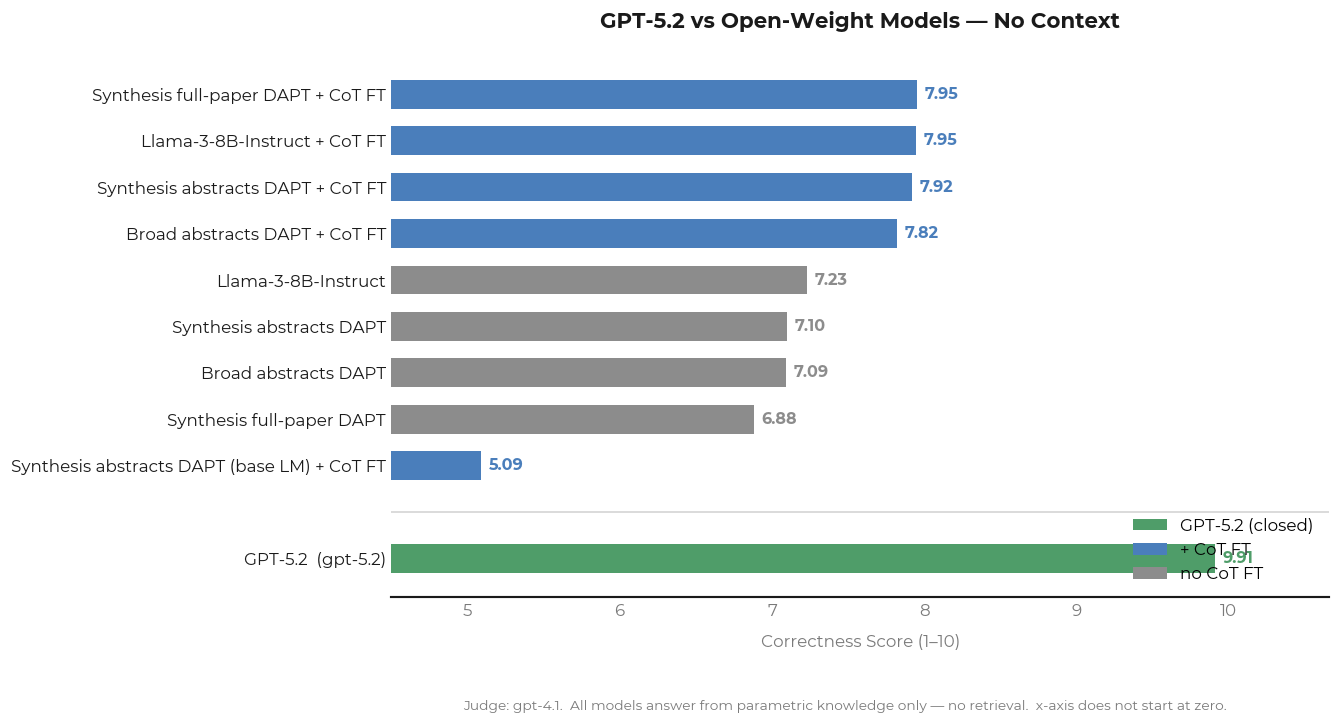

In [8]:
# ---------------- figure (matches the 30e design language) ----------------
ORANGE, BLUE, GREEN, GREY = '#D2782F', '#4A7EBB', '#4F9D69', '#8C8C8C'
INK, MUTED, RULE = '#1A1A1A', '#7A7A7A', '#D8D8D8'
mpl.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
                     'font.family': 'Montserrat', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.spines.left': False, 'axes.edgecolor': INK,
                     'axes.linewidth': 1.4, 'xtick.color': MUTED, 'ytick.color': INK,
                     'xtick.major.size': 0, 'ytick.major.size': 0, 'axes.grid': False,
                     'axes.labelcolor': MUTED, 'legend.frameon': False})

labels, vals, colors = [], [], []
for internal, label, is_cot in TABLE1:
    s = local_scores(internal, 'no_context')
    labels.append(label); vals.append(float(np.mean(list(s.values()))))
    colors.append(BLUE if is_cot else GREY)
labels.append(''); vals.append(np.nan); colors.append('none')          # separator slot
labels.append(f'GPT-5.2  ({GEN_MODEL})'); vals.append(g41); colors.append(GREEN)

order = list(np.argsort([-v if np.isfinite(v) else 1e9 for v in vals[:-2]])) + [len(vals) - 2, len(vals) - 1]
labels = [labels[i] for i in order]; vals = [vals[i] for i in order]; colors = [colors[i] for i in order]

y = np.arange(len(vals))
fig, ax = plt.subplots(figsize=(11, 6.4))
ax.barh(y, vals, height=0.62, color=colors, zorder=3)
for yi, v, c in zip(y, vals, colors):
    if np.isfinite(v):
        ax.text(v + 0.05, yi, f'{v:.2f}', va='center', ha='left',
                fontsize=10.5, fontweight='bold', color=c, zorder=5)
ax.axhline(len(vals) - 2, color=RULE, linewidth=1.2, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
finite = [v for v in vals if np.isfinite(v)]
ax.set_xlim(np.floor((min(finite) - 0.55) * 2) / 2, max(finite) + 0.75)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
ax.set_xlabel('Correctness Score (1\u201310)', labelpad=10)
ax.set_title('GPT-5.2 vs Open-Weight Models \u2014 No Context', fontweight='bold',
             color=INK, pad=18, fontsize=14)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GREEN, label='GPT-5.2 (closed)'),
                   Patch(facecolor=BLUE, label='+ CoT FT'),
                   Patch(facecolor=GREY, label='no CoT FT')],
          loc='lower right', ncol=1)
fig.text(0.5, -0.05,
         f'Judge: {PRIMARY}.  All models answer from parametric knowledge only \u2014 no retrieval.  '
         'x-axis does not start at zero.', fontsize=9, color=MUTED, ha='center')

os.makedirs('figures_30e', exist_ok=True)
for ext in ('svg', 'png'):
    fig.savefig(f'figures_30e/fig6_gpt52_vs_local_{TS}.{ext}', format=ext)
print(f'saved figures_30e/fig6_gpt52_vs_local_{TS}.{{svg,png}}')
plt.show()